# Problem 3 - Classification Simulation, Metrics, and Tuning

This notebook compares classifiers in two simulated binary-classification scenarios: one with a
roughly linear decision boundary and one with a nonlinear boundary. KNN and tree depth are tuned
by cross-validation inside the training data.


In [1]:
### IMPORTS
# Core data and numerical libraries.
import pandas as pd
import numpy as np

# Plotting tools for accuracy comparisons and confusion matrices.
import matplotlib.pyplot as plt
plt.style.use('default')

# Classification models.
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Model-selection, preprocessing, metrics, and pipelines.
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


In [2]:
### GLOBAL VARS
# Reproducible seed used for all classification simulations.
RANDOM_SEED = 123


## Data Simulation

The linear scenario generates labels from a noisy linear score. The nonlinear scenario generates
labels from a noisy radius-like score, so methods with nonlinear decision boundaries should have an
advantage.


In [3]:
def simulate_classification_data(scenario, n, random_state):
    """Simulate binary classification data for a named scenario."""

    rng = np.random.default_rng(random_state)
    X = rng.normal(size=(n, 5))

    if scenario == "linear_boundary":
        # A linear combination of predictors defines the class probability boundary.
        score = 1.2 * X[:, 0] - 1.0 * X[:, 1] + 0.6 * X[:, 2] + rng.normal(scale=0.75, size=n)
        y = (score > 0.0).astype(int)
    elif scenario == "nonlinear_boundary":
        # A curved boundary depends on squared predictors and an interaction-like term.
        score = X[:, 0] ** 2 + X[:, 1] ** 2 + 0.7 * X[:, 2] - 0.5 * X[:, 3]
        score = score + rng.normal(scale=0.45, size=n)
        y = (score > 1.7).astype(int)
    else:
        raise ValueError("scenario must be 'linear_boundary' or 'nonlinear_boundary'")

    return X, y


## Classifier Fitting Helpers

Every model is trained only on training data. KNN and decision-tree depth are tuned by stratified
cross-validation inside the training set, which keeps class proportions similar across folds.


In [4]:
def make_classifier_specs(random_state):
    """Return classifier specifications and optional tuning grids."""

    return {
        "Logistic Regression": {
            "estimator": make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=2000, random_state=random_state),
            ),
            "param_grid": None,
        },
        "LDA": {
            "estimator": make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
            "param_grid": None,
        },
        "QDA": {
            "estimator": make_pipeline(StandardScaler(), QuadraticDiscriminantAnalysis(reg_param=0.01)),
            "param_grid": None,
        },
        "KNN tuned": {
            "estimator": make_pipeline(StandardScaler(), KNeighborsClassifier()),
            "param_grid": {"kneighborsclassifier__n_neighbors": [3, 5, 9, 15, 25]},
        },
        "Tree tuned": {
            "estimator": DecisionTreeClassifier(random_state=random_state),
            "param_grid": {"max_depth": [2, 3, 4, 6, 8, None]},
        },
        "Random Forest": {
            "estimator": RandomForestClassifier(n_estimators=150, random_state=random_state),
            "param_grid": None,
        },
    }


def fit_and_predict_classifier(spec, X_train, y_train, X_test, random_state):
    """Fit one classifier specification and return test predictions plus tuning details."""

    if spec["param_grid"] is None:
        # Untuned models are fit once on the full training set.
        model = spec["estimator"]
        model.fit(X_train, y_train)
        best_params = {}
    else:
        # Tuned models choose hyperparameters by stratified CV within the training data only.
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        model = GridSearchCV(
            estimator=spec["estimator"],
            param_grid=spec["param_grid"],
            scoring="accuracy",
            cv=inner_cv,
            n_jobs=None,
        )
        model.fit(X_train, y_train)
        best_params = model.best_params_

    preds = model.predict(X_test)
    return preds, best_params


## Simulation Study Function


In [5]:
def classification_study(scenarios, nrep=25, train_size=250, test_size=1000, makePlot=True, random_state=RANDOM_SEED):
    """Compare classifiers across scenarios and replicates using test accuracy."""

    rng = np.random.default_rng(random_state)
    rows = []
    first_rep_predictions = {}

    for scenario in scenarios:
        for rep in range(nrep):
            # Independent train and test samples give an honest estimate of generalization.
            train_seed = int(rng.integers(0, 1_000_000_000))
            test_seed = int(rng.integers(0, 1_000_000_000))
            X_train, y_train = simulate_classification_data(scenario, train_size, train_seed)
            X_test, y_test = simulate_classification_data(scenario, test_size, test_seed)

            classifier_specs = make_classifier_specs(random_state + rep)

            for method_name, spec in classifier_specs.items():
                preds, best_params = fit_and_predict_classifier(spec, X_train, y_train, X_test, random_state + rep)
                acc = accuracy_score(y_test, preds)

                rows.append({
                    "scenario": scenario,
                    "replicate": rep,
                    "method": method_name,
                    "test_accuracy": acc,
                    "best_params": best_params,
                })

                # Save predictions from the first replicate so we can later show a confusion matrix.
                if rep == 0:
                    first_rep_predictions[(scenario, method_name)] = {
                        "y_test": y_test,
                        "preds": preds,
                        "best_params": best_params,
                    }

    results = pd.DataFrame(rows)

    summary = (
        results
        .groupby(["scenario", "method"], as_index=False)
        .agg(
            mean_test_accuracy=("test_accuracy", "mean"),
            sd_test_accuracy=("test_accuracy", "std"),
        )
        .sort_values(["scenario", "mean_test_accuracy"], ascending=[True, False])
        .reset_index(drop=True)
    )

    if makePlot:
        # Boxplots show both center and replicate-to-replicate variability by method.
        fig, axes = plt.subplots(1, len(scenarios), figsize=(14, 5), sharey=True)
        if len(scenarios) == 1:
            axes = [axes]

        for ax, scenario in zip(axes, scenarios):
            scenario_results = results[results["scenario"] == scenario]
            ordered_methods = (
                summary[summary["scenario"] == scenario]
                .sort_values("mean_test_accuracy", ascending=False)["method"]
                .tolist()
            )
            plot_data = [
                scenario_results.loc[scenario_results["method"] == method, "test_accuracy"]
                for method in ordered_methods
            ]
            ax.boxplot(plot_data, labels=ordered_methods, vert=True)
            ax.set_title(scenario)
            ax.set_ylabel("test accuracy")
            ax.tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()

    return results, summary, first_rep_predictions


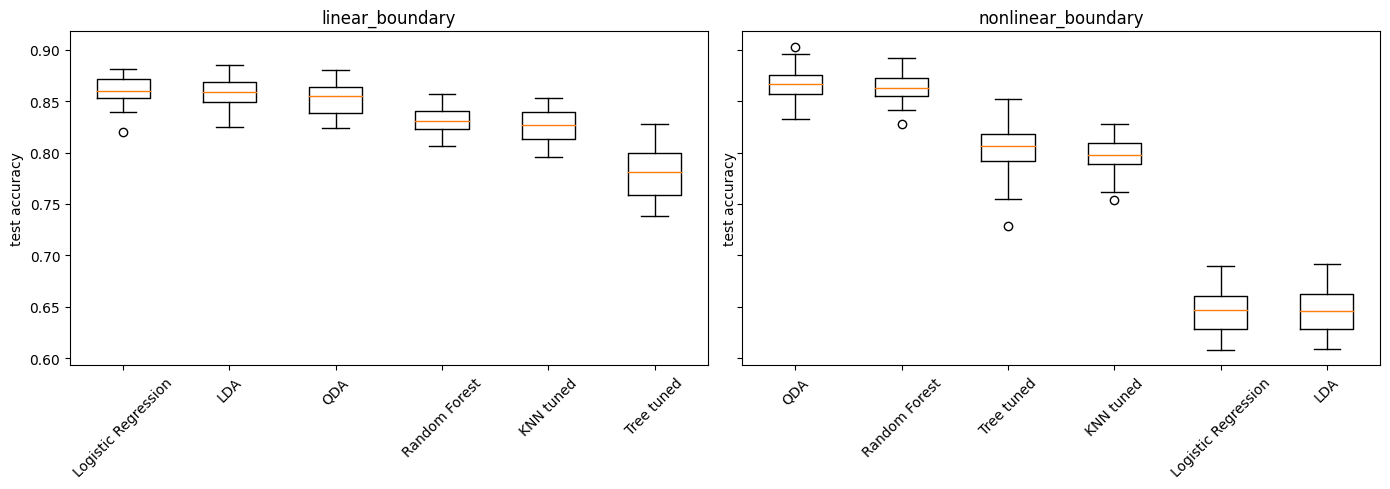

,scenario,method,mean_test_accuracy,sd_test_accuracy
0,linear_boundary,Logistic Regression,0.85972,0.014435
1,linear_boundary,LDA,0.85932,0.014628
2,linear_boundary,QDA,0.85416,0.015721
3,linear_boundary,Random Forest,0.83096,0.013343
4,linear_boundary,KNN tuned,0.82624,0.016264
5,linear_boundary,Tree tuned,0.78228,0.025599
6,nonlinear_boundary,QDA,0.86868,0.017009
7,nonlinear_boundary,Random Forest,0.86216,0.014267
8,nonlinear_boundary,Tree tuned,0.80220,0.028253
9,nonlinear_boundary,KNN tuned,0.79840,0.017277


In [6]:
# Run the classification study for both requested scenarios.
classification_results, classification_summary, first_rep_predictions = classification_study(
    scenarios=["linear_boundary", "nonlinear_boundary"],
    nrep=25,
    train_size=250,
    test_size=1000,
    makePlot=True,
)

# Report mean test accuracy by method and scenario.
classification_summary


## Confusion Matrix for a Best Method


Scenario: nonlinear_boundary
Best method by mean test accuracy: QDA
First-replicate tuning details: {}


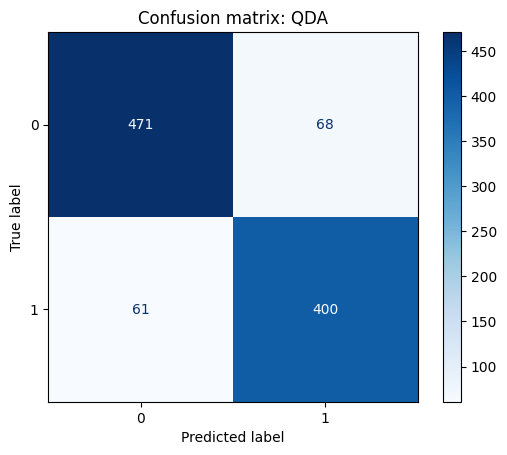

In [7]:
# Choose the best mean-accuracy method in the nonlinear scenario and show its first-replicate confusion matrix.
scenario_to_show = "nonlinear_boundary"
best_method = (
    classification_summary[classification_summary["scenario"] == scenario_to_show]
    .sort_values("mean_test_accuracy", ascending=False)
    .iloc[0]["method"]
)

confusion_info = first_rep_predictions[(scenario_to_show, best_method)]
cm = confusion_matrix(confusion_info["y_test"], confusion_info["preds"])

print(f"Scenario: {scenario_to_show}")
print(f"Best method by mean test accuracy: {best_method}")
print(f"First-replicate tuning details: {confusion_info['best_params']}")

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(cmap="Blues")
plt.title(f"Confusion matrix: {best_method}")
plt.show()


## Interpretation

Logistic regression and LDA are expected to work well when the true boundary is approximately
linear. QDA, KNN, trees, and random forests can capture more nonlinear structure, so they often
improve in the nonlinear scenario. Stratified splitting and stratified cross-validation are useful
because they preserve class proportions in training and validation folds, making accuracy estimates
less sensitive to accidental class imbalance. Training accuracy alone is not sufficient because a very
flexible classifier can memorize training data and still generalize poorly to new data.
